In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load CSV
df = pd.read_csv(r'C:\Users\vikas\online_retail_II.csv', encoding='latin-1')

# Basic cleaning
df.dropna(subset=['Customer ID'], inplace=True)
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Create revenue column
df['Revenue'] = df['Quantity'] * df['Price']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')

print(f"Total records: {len(df):,}")
print(f"Total revenue: £{df['Revenue'].sum():,.0f}")
print(df.head())

Total records: 805,549
Total revenue: £17,743,429
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  Revenue    Month  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom     83.4  2009-12  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom     81.0  2009-12  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom     81.0  2009-12  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom    100.8  2009-12  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom     30.0  2009-12  


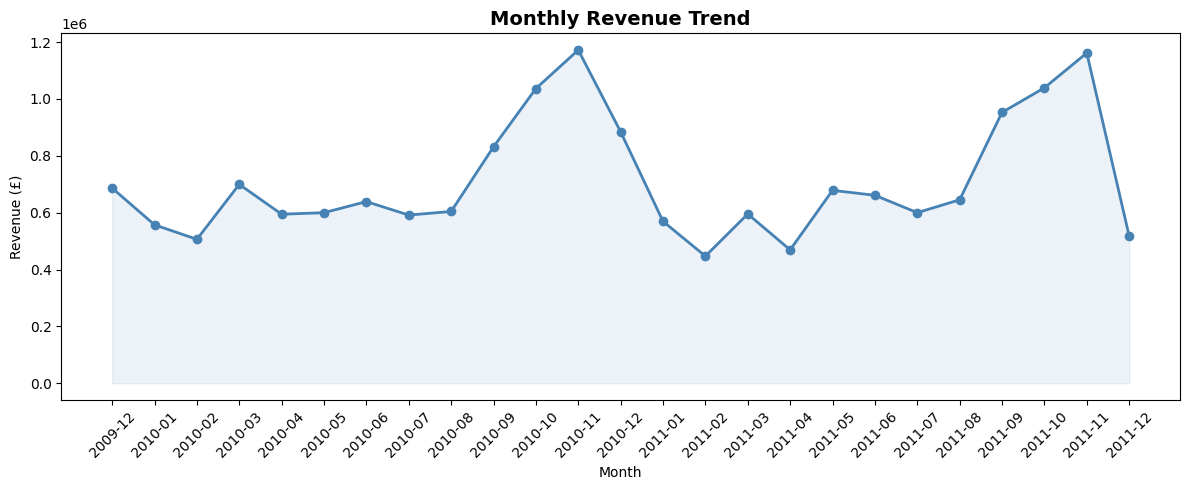

Chart 1 saved!


In [2]:
monthly = df.groupby('Month')['Revenue'].sum().reset_index()
monthly['Month_str'] = monthly['Month'].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly['Month_str'], monthly['Revenue'], marker='o', color='steelblue', linewidth=2)
plt.fill_between(range(len(monthly)), monthly['Revenue'], alpha=0.1, color='steelblue')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('chart1_monthly_revenue.png', dpi=150)
plt.show()
print("Chart 1 saved!")

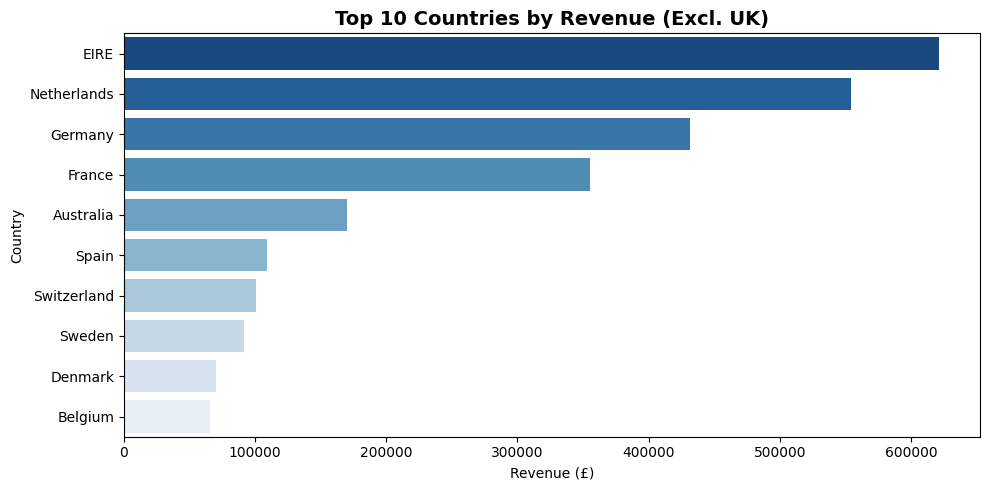

Chart 2 saved!


In [3]:
country_rev = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
country_rev = country_rev[country_rev.index != 'United Kingdom'].head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=country_rev.values, y=country_rev.index, palette='Blues_r')
plt.title('Top 10 Countries by Revenue (Excl. UK)', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (£)')
plt.tight_layout()
plt.savefig('chart2_top_countries.png', dpi=150)
plt.show()
print("Chart 2 saved!")

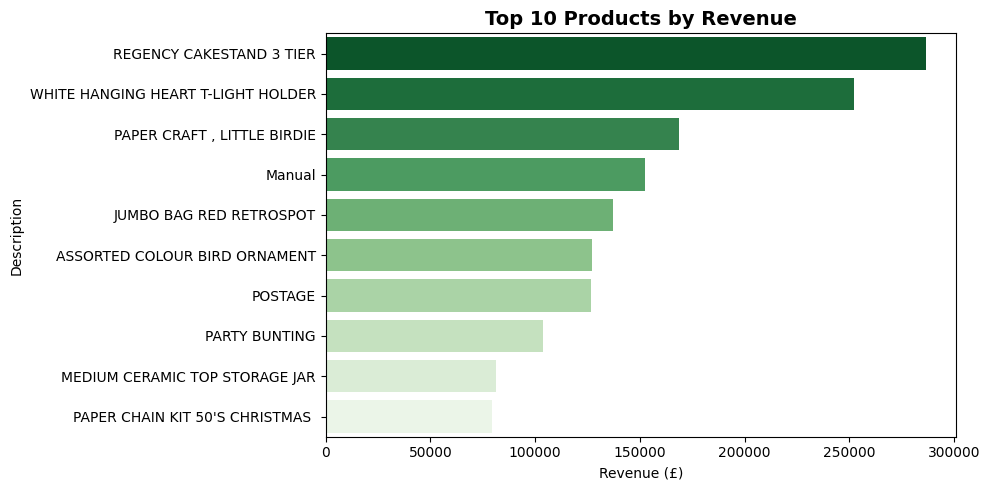

Chart 3 saved!


In [4]:
product_rev = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=product_rev.values, y=product_rev.index, palette='Greens_r')
plt.title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (£)')
plt.tight_layout()
plt.savefig('chart3_top_products.png', dpi=150)
plt.show()
print("Chart 3 saved!")

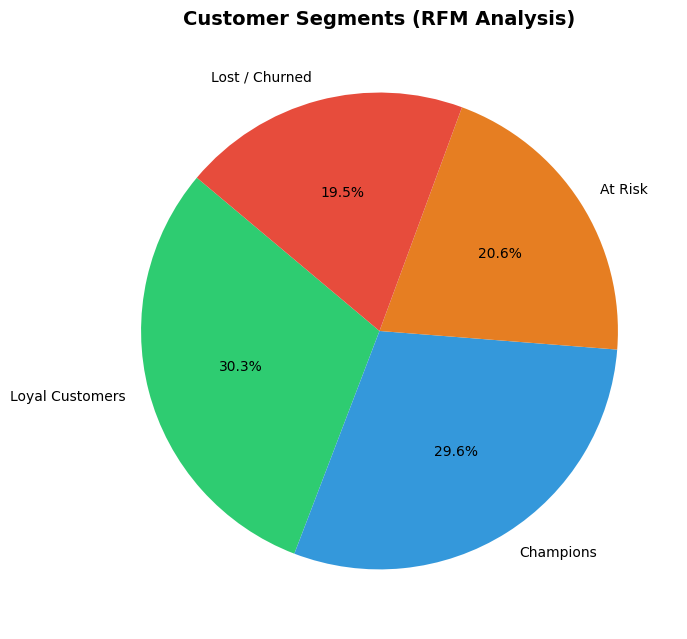

Segment
Loyal Customers    1781
Champions          1738
At Risk            1212
Lost / Churned     1147
Name: count, dtype: int64
Chart 4 saved!


In [5]:
import numpy as np

snapshot_date = df['InvoiceDate'].max() + pd.DateOffset(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('Revenue', 'sum')
).reset_index()

# Score each dimension 1-4
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=4, labels=[1,2,3,4])
rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

# Segment
def segment(score):
    if score >= 10: return 'Champions'
    elif score >= 7: return 'Loyal Customers'
    elif score >= 5: return 'At Risk'
    else: return 'Lost / Churned'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

seg_counts = rfm['Segment'].value_counts()
colors = ['#2ecc71','#3498db','#e67e22','#e74c3c']

plt.figure(figsize=(7,7))
plt.pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=140)
plt.title('Customer Segments (RFM Analysis)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_rfm_segments.png', dpi=150)
plt.show()
print(rfm['Segment'].value_counts())
print("Chart 4 saved!")

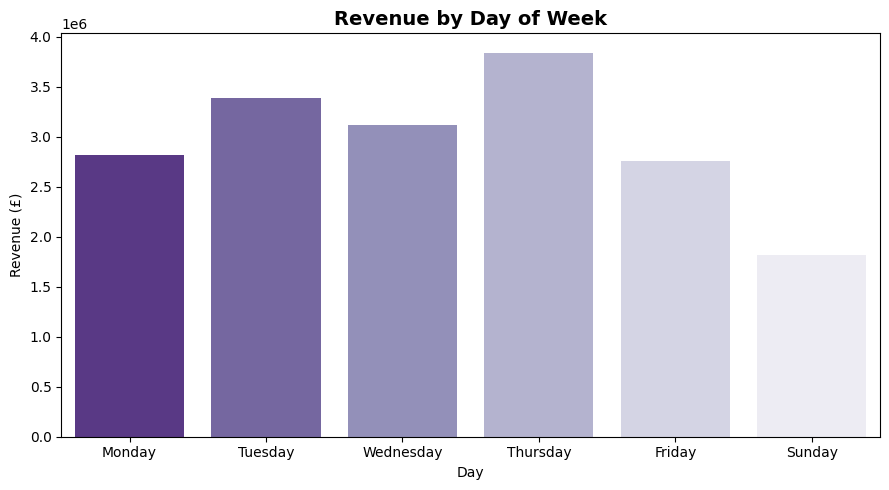

Chart 5 saved!


In [6]:
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Sunday']
day_rev = df.groupby('DayOfWeek')['Revenue'].sum().reindex(day_order)

plt.figure(figsize=(9, 5))
sns.barplot(x=day_rev.index, y=day_rev.values, palette='Purples_r')
plt.title('Revenue by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('chart5_day_of_week.png', dpi=150)
plt.show()
print("Chart 5 saved!")

In [7]:
summary = {
    'Metric': [
        'Total Revenue', 'Total Orders', 'Total Customers',
        'Avg Order Value', 'Top Country (excl UK)', 'Champions %'
    ],
    'Value': [
        f"£{df['Revenue'].sum():,.0f}",
        f"{df['Invoice'].nunique():,}",
        f"{df['Customer ID'].nunique():,}",
        f"£{df.groupby('Invoice')['Revenue'].sum().mean():,.0f}",
        country_rev.index[0],
        f"{(rfm['Segment']=='Champions').mean()*100:.1f}%"
    ]
}

with pd.ExcelWriter('ecommerce_dashboard.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Raw Data', index=False)
    pd.DataFrame(summary).to_excel(writer, sheet_name='KPI Summary', index=False)
    monthly.to_excel(writer, sheet_name='Monthly Revenue', index=False)
    rfm.to_excel(writer, sheet_name='RFM Segments', index=False)
    country_rev.reset_index().to_excel(writer, sheet_name='Country Revenue', index=False)
    product_rev.reset_index().to_excel(writer, sheet_name='Top Products', index=False)

print("Excel dashboard exported!")
print("All done! Check your folder for 5 chart PNGs + ecommerce_dashboard.xlsx")

Excel dashboard exported!
All done! Check your folder for 5 chart PNGs + ecommerce_dashboard.xlsx
